In [7]:
#IMPORTAÇÃO E PREPARAÇÃO DOS DADOS APRIMORADA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import sys

import warnings
warnings.filterwarnings('ignore')

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid", palette="muted")

print("A verificar os ficheiros na máquina virtual do Colab...")

# Lista dos ficheiros necessários para esta etapa
ficheiros_necessarios = [
    'olist_customers_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv'
]

# Descobre onde os ficheiros estão (na raiz ou dentro de sample_data)
base_path = ''
if all(os.path.exists(f'sample_data/{f}') for f in ficheiros_necessarios):
    base_path = 'sample_data/'
else:
    # Verifica se falta algum ficheiro na raiz
    ficheiros_em_falta = [f for f in ficheiros_necessarios if not os.path.exists(f)]
    if ficheiros_em_falta:
        print("\n❌ ERRO: Faltam ficheiros no Colab!")
        print("O Colab apaga os ficheiros quando a sessão reinicia. Por favor, faz o upload destes ficheiros:")
        for f in ficheiros_em_falta:
            print(f"  -> {f}")
        print("\nArrasta-os para a barra lateral esquerda e corre esta célula novamente.")
        sys.exit() # Para a execução do código de forma limpa

print(f"Ficheiros encontrados no diretório: '{base_path if base_path else 'raiz (/) '}'. A carregar dados...")

df_customers = pd.read_csv(f'{base_path}olist_customers_dataset.csv')
df_orders = pd.read_csv(f'{base_path}olist_orders_dataset.csv')
df_items = pd.read_csv(f'{base_path}olist_order_items_dataset.csv')
df_payments = pd.read_csv(f'{base_path}olist_order_payments_dataset.csv')

# Unificando as bases
df_merged = pd.merge(df_orders, df_customers, on='customer_id', how='inner')
df_merged = pd.merge(df_merged, df_items, on='order_id', how='inner')
df_master = pd.merge(df_merged, df_payments, on='order_id', how='inner')

# Limpeza de nulos (pedidos não entregues)
df_clean = df_master.dropna(subset=['order_delivered_customer_date', 'order_approved_at'])

# Selecionando as variáveis numéricas para a EDA e PCA
features = ['price', 'freight_value', 'payment_installments', 'payment_value']
df_num = df_clean[features]

print(f"Base preparada para a EDA: {df_num.shape[0]} linhas e {df_num.shape[1]} variáveis numéricas.\n")


A verificar os ficheiros na máquina virtual do Colab...
Ficheiros encontrados no diretório: 'sample_data/'. A carregar dados...
Base preparada para a EDA: 115019 linhas e 4 variáveis numéricas.



In [8]:
#1. ESTATÍSTICAS DESCRITIVAS
print("--- Estatísticas Descritivas Principais ---")
display(df_num.describe().round(2))

--- Estatísticas Descritivas Principais ---


,price,freight_value,payment_installments,payment_value
count,115019.00,115019.00,115019.00,115019.00
mean,120.08,20.00,2.94,171.92
std,183.04,15.74,2.77,266.12
min,0.85,0.00,0.00,0.00
25%,39.90,13.08,1.00,60.85
50%,74.90,16.28,2.00,108.19
75%,133.00,21.18,4.00,188.94
max,6735.00,409.68,24.00,13664.08


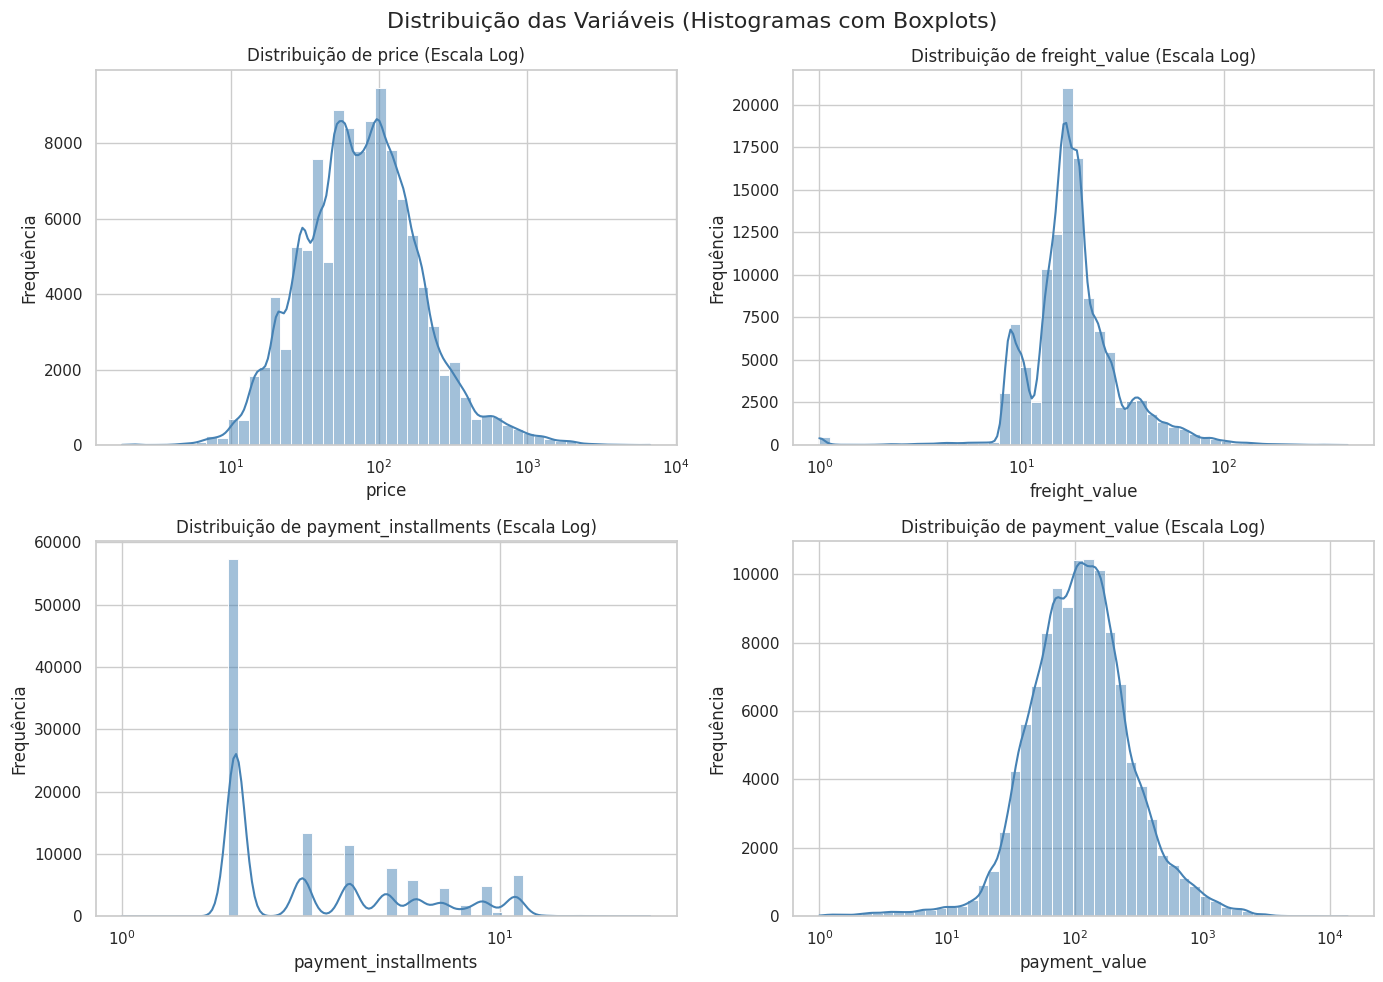

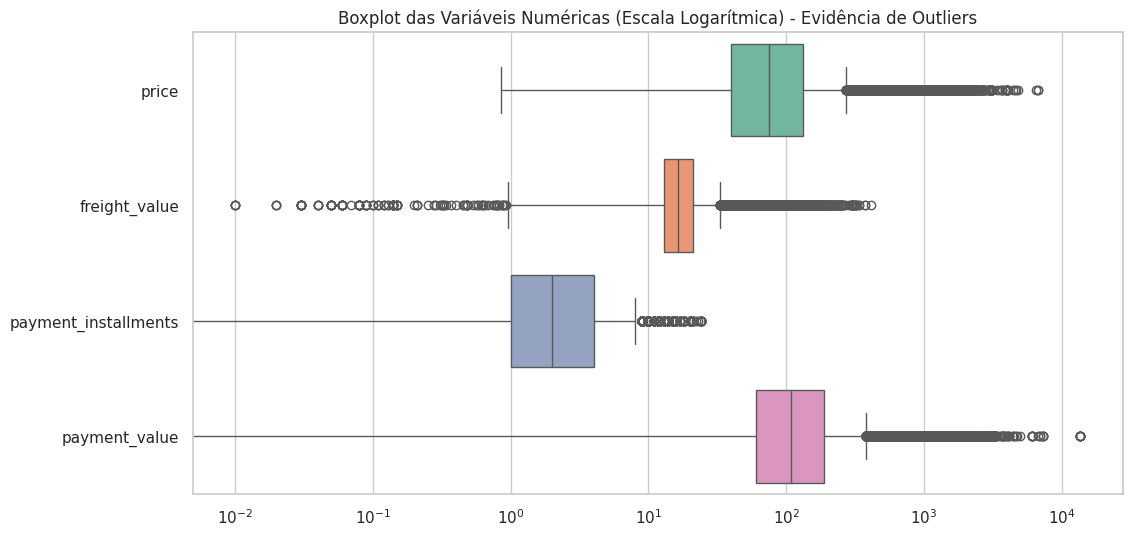

In [9]:
#2. DISTRIBUIÇÕES: HISTOGRAMAS E BOXPLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuição das Variáveis (Histogramas com Boxplots)', fontsize=16)

for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    # Usamos escala logarítmica para os histogramas lidarem com os outliers
    sns.histplot(df_num[col] + 1, bins=50, kde=True, log_scale=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribuição de {col} (Escala Log)')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Boxplots para evidenciar os Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_num, orient="h", palette="Set2")
plt.xscale('log')
plt.title('Boxplot das Variáveis Numéricas (Escala Logarítmica) - Evidência de Outliers')
plt.show()


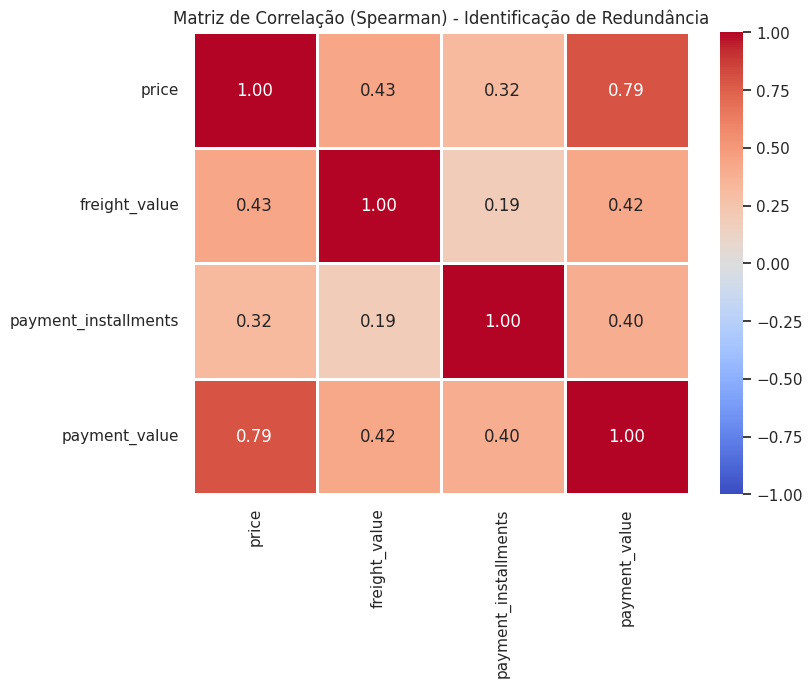

In [10]:
#3. MATRIZ DE CORRELAÇÃO (Spearman)
# Spearman lida melhor com dados que não têm uma distribuição normal perfeita
corr_matrix = df_num.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, vmin=-1, vmax=1)
plt.title('Matriz de Correlação (Spearman) - Identificação de Redundância')
plt.show()


A aplicar o StandardScaler e a gerar o PCA...
Variância explicada pelo PC1: 54.83%
Variância explicada pelo PC2: 21.15%
Total de informação retida em 2D: 75.98%



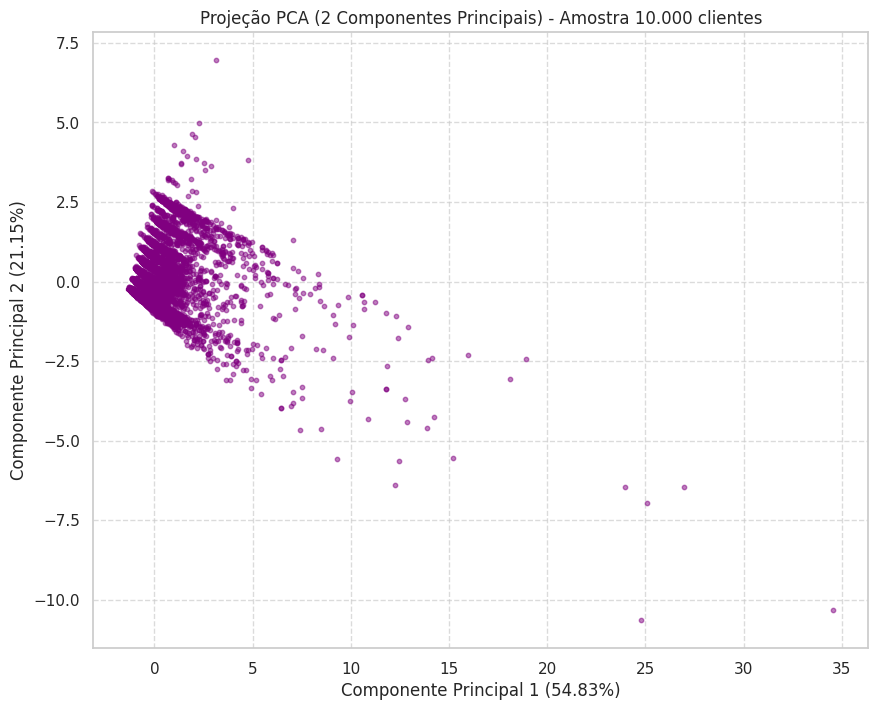

In [11]:
#4. NORMALIZAÇÃO E IMPACTO NA PROXIMIDADE (PCA)
print("A aplicar o StandardScaler e a gerar o PCA...")
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

# Aplicando o PCA para 2 componentes (2D)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

# Variância Explicada
var_expl = pca.explained_variance_ratio_
print(f"Variância explicada pelo PC1: {var_expl[0]*100:.2f}%")
print(f"Variância explicada pelo PC2: {var_expl[1]*100:.2f}%")
print(f"Total de informação retida em 2D: {(var_expl[0] + var_expl[1])*100:.2f}%\n")

# Gráfico do PCA (Amostra de 10k para o Colab não travar o ecrã)
amostra_idx = np.random.choice(pca_features.shape[0], 10000, replace=False)
pca_amostra = pca_features[amostra_idx]

plt.figure(figsize=(10, 8))
plt.scatter(pca_amostra[:, 0], pca_amostra[:, 1], alpha=0.5, c='purple', s=10)
plt.title('Projeção PCA (2 Componentes Principais) - Amostra 10.000 clientes')
plt.xlabel(f'Componente Principal 1 ({var_expl[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({var_expl[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()